# K-Armed-Bandit Experiment

For this experiment, we create 10 armed-bandits with normally distributed reward $\mathcal{N(q_{*}(a), 1)}$. Each $q_{*}(a)$ is sampled from a normal distribution $\mathcal{N(0, 1)}$.

In [4]:
from k_arm_bandit.bandits import OneArmBandit, plot_average_rewards, run_experiment

# initialize the K-armed bandit problem
bandits = [OneArmBandit.random() for _ in range(10)]

for b in bandits:
    print(f"Bandit: {b}, Mean: {b.mu}, Std: {b.sigma}")

Bandit: OneArmBandit(mu=-0.86, sigma=1.00, n=0, q=0.00), Mean: -0.8606531243594706, Std: 1.0
Bandit: OneArmBandit(mu=0.07, sigma=1.00, n=0, q=0.00), Mean: 0.06746919476896476, Std: 1.0
Bandit: OneArmBandit(mu=-0.37, sigma=1.00, n=0, q=0.00), Mean: -0.36586252192835517, Std: 1.0
Bandit: OneArmBandit(mu=1.07, sigma=1.00, n=0, q=0.00), Mean: 1.0749309178817539, Std: 1.0
Bandit: OneArmBandit(mu=-0.81, sigma=1.00, n=0, q=0.00), Mean: -0.8110917251100974, Std: 1.0
Bandit: OneArmBandit(mu=-0.07, sigma=1.00, n=0, q=0.00), Mean: -0.06840600017153936, Std: 1.0
Bandit: OneArmBandit(mu=0.26, sigma=1.00, n=0, q=0.00), Mean: 0.26485287186660544, Std: 1.0
Bandit: OneArmBandit(mu=-1.65, sigma=1.00, n=0, q=0.00), Mean: -1.6476829132721116, Std: 1.0
Bandit: OneArmBandit(mu=1.19, sigma=1.00, n=0, q=0.00), Mean: 1.1911258166442524, Std: 1.0
Bandit: OneArmBandit(mu=0.30, sigma=1.00, n=0, q=0.00), Mean: 0.30470926189687636, Std: 1.0


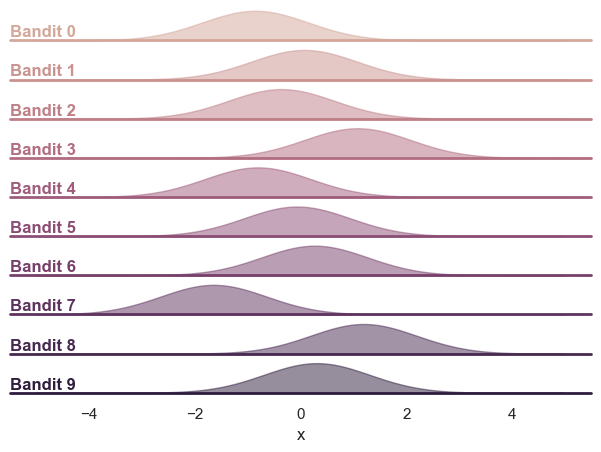

In [5]:
# create a plot of each bandit reward distribution
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
warnings.filterwarnings('ignore', category=UserWarning)

N_POINTS = 100
X_LIM = (-5, 5)

# Create the data
x = np.array([])
y = np.array([])
g = np.array([])
x_bandit = np.append(x, np.linspace(X_LIM[0], X_LIM[1], N_POINTS))


for i, bandit in enumerate(bandits):
    mu = bandit.mu
    sigma = 1
    # sample N_POINTS points from the normal distribution
    x = np.append(x, x_bandit)
    y = np.append(y, stats.norm.pdf(x_bandit, mu, sigma))
    g = np.append(g, [i] * N_POINTS)

df = pd.DataFrame(dict(x=x, g=g, y=y))

df["g"] = df["g"].apply(lambda x: f"Bandit {x:.0f}")

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=0.5, light=.7)
g = sns.FacetGrid(df, row="g", hue="g", aspect=15, height=0.5, palette=pal)


# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

# Fill the area under the curve
g.map(plt.fill_between, "x", "y", alpha=.5, clip_on=False)

# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .3, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)



g.map(label, "x")

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True);

The above figure shows the true reward distribution of each arm.

Let's now run a single experiment with our 10 armed-bandits. We will use the epsilon-greedy algorithm with $\epsilon = 0.1$ and a learning rate of $\alpha = 0.1$. The agent will select an arm to pull, receive a reward, and update its estimate of the expected reward for that arm.

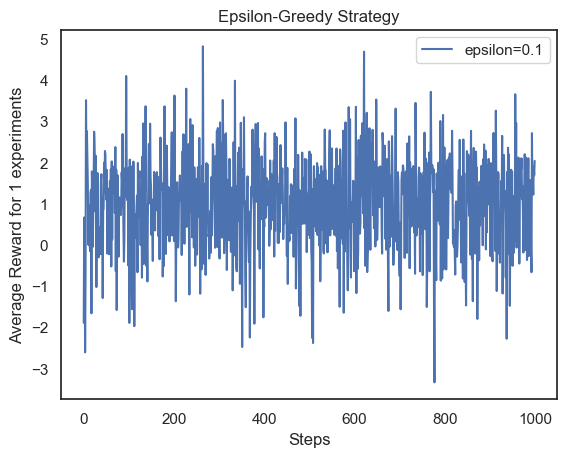

In [6]:
# run a single experiment
epsilons = [0.1]
rewards = run_experiment(bandits, epsilons, n_actions=1_000, n_experiments=1)
plot_average_rewards(rewards, epsilons)

As we can see, the reward distribution is fairly noisy. In order to mitigate for the noise, we will run the experiment 2,000 times and plot the average reward for each action.

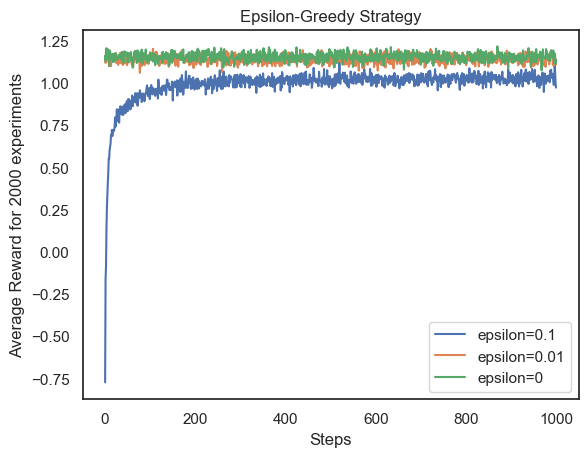

In [7]:
N_EXPERIMENTS = 2_000
# run the experiment

rewards = run_experiment(bandits, epsilons=[0.1, 0.01, 0], n_actions=1_000, n_experiments=N_EXPERIMENTS)
plot_average_rewards(rewards, epsilons=[0.1, 0.01, 0])